<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h2 style="margin-bottom:6px;">Learning Day 9 — Ensemble Methods: Bagging &amp; Stacking</h2>
<p style="margin-top:0; font-size:15px;">
<strong>Notebook 02:</strong> Data Preparation and Baseline Models
</p>

<div style="border-left:4px solid #38bdf8; padding:10px 14px; margin:12px 0; background:var(--vscode-editorWidget-background); border-radius:6px;">
<strong>Purpose:</strong> Prepare the Bank Marketing dataset for ensemble modelling and build clean baseline models before Random Forest, stacking, OOF stacking, blending, and three-layer stacking.
</div>

<p>
In the detailed theory discussion, we learned that ensemble methods combine model opinions. Before building the ensemble, we need a clean, reliable modelling table, fair train/test split, preprocessing pipeline, and baseline model results.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom:6px;">What this notebook covers</h3>

<table style="border-collapse:collapse; width:100%; font-size:14px;">
<thead>
<tr>
<th style="text-align:left; border-bottom:1px solid #888; padding:6px;">Section</th>
<th style="text-align:left; border-bottom:1px solid #888; padding:6px;">Why it matters</th>
</tr>
</thead>
<tbody>
<tr><td style="padding:6px; border-bottom:1px solid #555;">Load Bank Marketing data</td><td style="padding:6px; border-bottom:1px solid #555;">Creates the customer-campaign prediction dataset.</td></tr>
<tr><td style="padding:6px; border-bottom:1px solid #555;">Inspect target and features</td><td style="padding:6px; border-bottom:1px solid #555;">Checks class balance and data quality before modelling.</td></tr>
<tr><td style="padding:6px; border-bottom:1px solid #555;">Train/test split</td><td style="padding:6px; border-bottom:1px solid #555;">Keeps a fair holdout test set for later model comparison.</td></tr>
<tr><td style="padding:6px; border-bottom:1px solid #555;">Preprocessing pipeline</td><td style="padding:6px; border-bottom:1px solid #555;">Encodes categorical columns and scales numeric columns safely.</td></tr>
<tr><td style="padding:6px; border-bottom:1px solid #555;">Baseline models</td><td style="padding:6px; border-bottom:1px solid #555;">Gives simple reference models before Random Forest and stacking.</td></tr>
<tr><td style="padding:6px;">Save reusable outputs</td><td style="padding:6px;">Stores reports and trained objects for later notebooks.</td></tr>
</tbody>
</table>

<div style="border-left:4px solid #f59e0b; padding:10px 14px; margin:12px 0; background:var(--vscode-editorWidget-background); border-radius:6px;">
<strong>Important point for clarity:</strong> This notebook is not yet the ensemble notebook. It builds the clean project foundation so that the ensemble results later are fair and trustworthy.
</div>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom:6px;">Dataset source and expected business problem</h3>
<p>
The selected dataset is <strong>Bank Marketing / Term Deposit Subscription Prediction</strong>. The business question is:
</p>

<div style="border-left:4px solid #22c55e; padding:10px 14px; margin:12px 0; background:var(--vscode-editorWidget-background); border-radius:6px;">
Can we predict whether a customer will subscribe to a term deposit after a marketing campaign?
</div>

<p>
The target column is usually <code>deposit</code> in the Kaggle version or <code>y</code> in the UCI version. Both represent whether the customer subscribed.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom:6px;">Setup</h3>
<p>
The next cell imports the libraries, creates clean relative project folders, and sets a fixed random seed so results are reproducible.
</p>

</div>

In [1]:
# Notebook 02 setup
# Goal: prepare data and train baseline models before ensemble modelling.

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
import joblib

# Fixed seed keeps train/test split and model results reproducible.
RANDOM_STATE = 42

# Relative folders only — no personal/local paths.
data_dir = Path("data") / "bank_marketing"
processed_dir = Path("data") / "processed"
reports_dir = Path("reports")
models_dir = Path("models")

for folder in [data_dir, processed_dir, reports_dir, models_dir]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project folders are ready.")
print(f"Raw data folder: {data_dir}")
print(f"Processed data folder: {processed_dir}")
print(f"Reports folder: {reports_dir}")
print(f"Models folder: {models_dir}")

Project folders are ready.
Raw data folder: data/bank_marketing
Processed data folder: data/processed
Reports folder: reports
Models folder: models


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom:6px;">Load the Bank Marketing dataset</h3>

<p>
This cell first checks for local files in <code>data/bank_marketing/</code>. If no file is found, it tries to download from Kaggle using <code>kagglehub</code>. If that is not available, it tries the public UCI repository URL.
</p>

<div style="border-left:4px solid #38bdf8; padding:10px 14px; margin:12px 0; background:var(--vscode-editorWidget-background); border-radius:6px;">
<strong>Important point for understanding:</strong> We keep the loading step flexible because the same dataset can appear as <code>bank.csv</code>, <code>bank-full.csv</code>, or <code>bank-additional-full.csv</code> depending on the source.
</div>

</div>

In [2]:
# Load Bank Marketing data from local folder, KaggleHub, or UCI fallback.
# The output variable `raw_data` will contain the original customer-campaign table.

import zipfile
import urllib.request

candidate_files = [
    data_dir / "bank.csv",
    data_dir / "bank-full.csv",
    data_dir / "bank-additional-full.csv",
    Path("data") / "bank.csv",
    Path("data") / "bank-full.csv",
    Path("data") / "bank-additional-full.csv",
]

found_file = None
for file_path in candidate_files:
    if file_path.exists():
        found_file = file_path
        break

# If not local, try KaggleHub. This requires internet and may require Kaggle access.
if found_file is None:
    try:
        import kagglehub
        kaggle_path = Path(kagglehub.dataset_download("janiobachmann/bank-marketing-dataset"))
        csv_files = list(kaggle_path.rglob("*.csv"))
        if csv_files:
            found_file = csv_files[0]
            print(f"Downloaded from KaggleHub: {found_file}")
    except Exception as error:
        print("KaggleHub download was not available in this environment.")
        print(f"Reason: {error}")

# If KaggleHub is not available, try public UCI zip.
if found_file is None:
    try:
        uci_zip_url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
        zip_path = data_dir / "bank_marketing_uci.zip"
        urllib.request.urlretrieve(uci_zip_url, zip_path)
        with zipfile.ZipFile(zip_path, "r") as outer_zip:
            outer_zip.extractall(data_dir)
        inner_zip = data_dir / "bank.zip"
        if inner_zip.exists():
            with zipfile.ZipFile(inner_zip, "r") as inner:
                inner.extractall(data_dir)
        for file_name in ["bank-full.csv", "bank.csv", "bank-additional-full.csv"]:
            possible_file = data_dir / file_name
            if possible_file.exists():
                found_file = possible_file
                print(f"Downloaded from UCI: {found_file}")
                break
    except Exception as error:
        print("UCI download was not available in this environment.")
        print(f"Reason: {error}")

if found_file is None:
    raise FileNotFoundError(
        "Bank Marketing CSV file was not found. "
        "Place bank.csv or bank-full.csv inside data/bank_marketing/, then rerun this cell."
    )

# UCI files often use semicolon separators; Kaggle versions may use comma separators.
try:
    raw_data = pd.read_csv(found_file)
    if raw_data.shape[1] == 1:
        raw_data = pd.read_csv(found_file, sep=";")
except Exception:
    raw_data = pd.read_csv(found_file, sep=";")

print(f"Loaded file: {found_file}")
print(f"Raw data shape: {raw_data.shape[0]:,} rows × {raw_data.shape[1]:,} columns")
display(raw_data.head())

100%|██████████| 142k/142k [00:00<00:00, 451kB/s]

Extracting files...
Downloaded from KaggleHub: /Users/ruturajmokashi/.cache/kagglehub/datasets/janiobachmann/bank-marketing-dataset/versions/1/bank.csv
Loaded file: /Users/ruturajmokashi/.cache/kagglehub/datasets/janiobachmann/bank-marketing-dataset/versions/1/bank.csv
Raw data shape: 11,162 rows × 17 columns


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom:6px;">Standardize column names and target</h3>
<p>
The Kaggle version may use <code>deposit</code> as the target, while the UCI version may use <code>y</code>. The next cell creates one consistent target column called <code>target_subscribed</code>.
</p>

</div>

In [3]:
# Standardize column names and create a clean binary target.
# `model_data` will be the cleaned modelling table used in all following steps.

model_data = raw_data.copy()
model_data.columns = (
    model_data.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

# Identify target column across common dataset versions.
if "deposit" in model_data.columns:
    original_target_col = "deposit"
elif "y" in model_data.columns:
    original_target_col = "y"
elif "subscribed" in model_data.columns:
    original_target_col = "subscribed"
else:
    raise ValueError("No target column found. Expected one of: deposit, y, subscribed.")

# Convert yes/no target to 1/0 for modelling.
model_data["target_subscribed"] = (
    model_data[original_target_col]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"yes": 1, "no": 0, "1": 1, "0": 0})
)

if model_data["target_subscribed"].isna().any():
    raise ValueError("Target conversion produced missing values. Check target labels.")

# Remove original target after creating the numeric target.
model_data = model_data.drop(columns=[original_target_col])

print(f"Original target column: {original_target_col}")
print("Clean target column: target_subscribed")
print(model_data["target_subscribed"].value_counts().rename(index={0: "No", 1: "Yes"}))

Original target column: deposit
Clean target column: target_subscribed
target_subscribed
No     5873
Yes    5289
Name: count, dtype: int64


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom:6px;">Data quality and target balance check</h3>
<p>
Before modelling, we inspect the target distribution, missing values, and feature types. This tells us whether accuracy alone is enough or whether we also need F1-score, recall, and ROC-AUC.
</p>

</div>

In [5]:
# Inspect target balance, missing values, and feature types.
# This step helps us understand:
# 1. Whether the target class is imbalanced.
# 2. Whether missing values need treatment.
# 3. Which columns are numeric and which are categorical for preprocessing.

# ------------------------------------------------------------
# 1. Target distribution
# ------------------------------------------------------------

# Count how many customers belong to each target class.
# target_subscribed = 0 means the customer did not subscribe.
# target_subscribed = 1 means the customer subscribed.
target_summary = (
    model_data["target_subscribed"]
    .value_counts()
    .rename(index={0: "Not subscribed", 1: "Subscribed"})
    .reset_index()
)

# Rename columns for a clean display table.
target_summary.columns = ["Target_Class", "Customer_Count"]

# Calculate the percentage share of each target class.
# This tells us whether the dataset is balanced or imbalanced.
target_summary["Share_%"] = (
    target_summary["Customer_Count"] / len(model_data) * 100
).round(2)


# ------------------------------------------------------------
# 2. Missing value summary
# ------------------------------------------------------------

# Count missing values column by column.
missing_summary = (
    model_data
    .isna()
    .sum()
    .reset_index()
)

# Rename columns for readability.
missing_summary.columns = ["Column", "Missing_Count"]

# Calculate missing value percentage for each column.
missing_summary["Missing_%"] = (
    missing_summary["Missing_Count"] / len(model_data) * 100
).round(2)

# Keep only columns that actually have missing values.
# Sorting helps us see the biggest missing-value problems first.
missing_summary = (
    missing_summary[missing_summary["Missing_Count"] > 0]
    .sort_values("Missing_Count", ascending=False)
)


# ------------------------------------------------------------
# 3. Feature type separation
# ------------------------------------------------------------

# Numeric columns are columns with integer or float values.
# These usually go through numeric preprocessing, such as scaling.
numeric_columns = (
    model_data
    .drop(columns=["target_subscribed"])       # Remove target column from features
    .select_dtypes(include=["int64", "float64"])
    .columns
    .tolist()
)

# Categorical columns are non-numeric columns.
# These usually need encoding before modelling.
categorical_columns = (
    model_data
    .drop(columns=["target_subscribed"])       # Remove target column from features
    .select_dtypes(exclude=["int64", "float64"])
    .columns
    .tolist()
)


# ------------------------------------------------------------
# 4. Display results
# ------------------------------------------------------------

print("Target distribution:")
display(target_summary)

print("\nMissing values:")
if missing_summary.empty:
    print("No missing values detected by pandas.")
else:
    display(missing_summary)

print("\nFeature groups:")
print(f"Numeric columns ({len(numeric_columns)}): {numeric_columns}")
print(f"Categorical columns ({len(categorical_columns)}): {categorical_columns}")

Target distribution:


,Target_Class,Customer_Count,Share_%
0,Not subscribed,5873,52.62
1,Subscribed,5289,47.38



Missing values:
No missing values detected by pandas.

Feature groups:
Numeric columns (7): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical columns (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom:6px;">Visual check: target distribution</h3>
<p>
This chart shows whether the subscription classes are balanced or imbalanced. If the positive class is small, we should not rely only on accuracy.
</p>

</div>

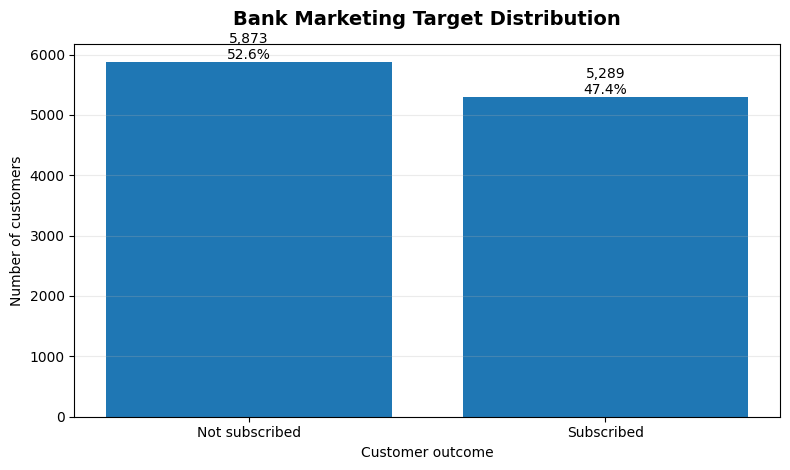

In [6]:
# Draw a BI-ready chart for the target distribution.
# This helps us quickly see whether the target is balanced or imbalanced.
# If one class is much smaller, accuracy alone may not be enough for evaluation.

plt.figure(figsize=(8, 4.8))

# Create bar chart using target class names and customer counts.
bars = plt.bar(
    target_summary["Target_Class"],
    target_summary["Customer_Count"]
)

# Add chart title and axis labels.
plt.title("Bank Marketing Target Distribution", fontsize=14, weight="bold", pad=14)
plt.xlabel("Customer outcome")
plt.ylabel("Number of customers")

# Add light horizontal grid for easier reading.
plt.grid(axis="y", alpha=0.25)

# Add labels on top of each bar.
# We show both:
# 1. customer count
# 2. percentage share
for bar, share in zip(bars, target_summary["Share_%"]):
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,   # Center text horizontally on the bar
        height,                              # Place text at the top of the bar
        f"{height:,.0f}\n{share:.1f}%",      # Count on first line, share on second line
        ha="center",
        va="bottom",
        fontsize=10,
    )

# Adjust spacing so labels and title fit neatly.
plt.tight_layout()
plt.show()

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Conclusion: Target Distribution</h3>

<p>
The target variable is almost balanced. The dataset contains
<b>5,873 customers who did not subscribe</b> and
<b>5,289 customers who subscribed</b>.
</p>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Key result:</b><br>
  The target split is <b>52.6% not subscribed</b> and <b>47.4% subscribed</b>.
  This means the dataset is suitable for fair model comparison.
</div>

<p>
Because the classes are not strongly imbalanced, <b>accuracy</b> can be used as a useful first metric.
However, this is still a marketing prediction problem, so we will also track
<b>precision</b>, <b>recall</b>, and <b>F1-score</b>.
</p>

<p>
From a business point of view, this is a strong dataset for Day 9 Ensemble Learning.
The models can learn patterns for both customer groups:
customers who are likely to subscribe and customers who are unlikely to subscribe.
</p>

<p>
This makes the dataset suitable for comparing <b>Decision Trees</b>,
<b>Random Forest</b>, <b>Stacking</b>, <b>Blending</b>, and other ensemble methods fairly.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom:6px;">Train/test split</h3>
<p>
We split the data before preprocessing to keep evaluation fair. The split is stratified, meaning both train and test sets keep a similar subscribed/not-subscribed ratio.
</p>

<div style="border-left:4px solid #38bdf8; padding:10px 14px; margin:12px 0; background:var(--vscode-editorWidget-background); border-radius:6px;">
<strong>Important point for understanding:</strong> The test set stays untouched until evaluation. This prevents us from accidentally designing the model around the test data.
</div>

</div>

In [7]:
# Separate features and target, then create a stratified train/test split.
# X_* contains input features; y_* contains the subscription outcome.

X = model_data.drop(columns=["target_subscribed"])
y = model_data["target_subscribed"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

split_summary = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Rows": [len(y_train), len(y_test)],
    "Subscribed_%": [y_train.mean() * 100, y_test.mean() * 100],
}).round({"Subscribed_%": 2})

display(split_summary)

X_train shape: (8929, 16)
X_test shape:  (2233, 16)
y_train shape: (8929,)
y_test shape:  (2233,)


,Dataset,Rows,Subscribed_%
0,Train,8929,47.38
1,Test,2233,47.38


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom:6px;">Preprocessing pipeline</h3>
<p>
Machine learning models need numeric inputs. The pipeline below handles numeric and categorical columns in a controlled way.
</p>

<table style="border-collapse:collapse; width:100%; font-size:14px;">
<thead><tr><th style="text-align:left; border-bottom:1px solid #888; padding:6px;">Feature type</th><th style="text-align:left; border-bottom:1px solid #888; padding:6px;">Steps</th><th style="text-align:left; border-bottom:1px solid #888; padding:6px;">Why</th></tr></thead>
<tbody>
<tr><td style="padding:6px; border-bottom:1px solid #555;">Numeric</td><td style="padding:6px; border-bottom:1px solid #555;">Median imputation + StandardScaler</td><td style="padding:6px; border-bottom:1px solid #555;">Keeps values usable for Logistic Regression and KNN.</td></tr>
<tr><td style="padding:6px;">Categorical</td><td style="padding:6px;">Most-frequent imputation + OneHotEncoder</td><td style="padding:6px;">Turns text categories into model-readable columns.</td></tr>
</tbody>
</table>

</div>

In [8]:
# Build preprocessing pipeline.
# The same preprocessor will be reused for Decision Tree, Logistic Regression, and KNN baselines.

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_columns),
        ("categorical", categorical_transformer, categorical_columns),
    ],
    remainder="drop",
)

print("Preprocessing pipeline is ready.")
print(f"Numeric features: {len(numeric_columns)}")
print(f"Categorical features: {len(categorical_columns)}")

Preprocessing pipeline is ready.
Numeric features: 7
Categorical features: 9


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom:6px;">Baseline models</h3>
<p>
Before advanced ensemble models, we train simple baselines. These results become the reference point for Random Forest, stacking, blending, and three-layer stacking.
</p>

<div style="border-left:4px solid #f59e0b; padding:10px 14px; margin:12px 0; background:var(--vscode-editorWidget-background); border-radius:6px;">
<strong>Important point for clarity:</strong> If an advanced ensemble improves only slightly but becomes much harder to explain, we need to judge whether the extra complexity is worth it.
</div>

</div>

In [9]:
# Define baseline models.
# DummyClassifier is the simplest baseline; other models are useful later for stacking.

baseline_models = {
    "Dummy Majority Baseline": DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=5),
}

print("Baseline models prepared:")
for model_name in baseline_models:
    print(f"- {model_name}")

Baseline models prepared:
- Dummy Majority Baseline
- Logistic Regression
- Decision Tree
- KNN


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom:6px;">Train and evaluate baseline models</h3>
<p>
The next cell trains each baseline model using the same preprocessing pipeline and evaluates it on the holdout test set.
</p>

</div>

In [10]:
# Train each baseline model and collect evaluation metrics.
# This gives us the first model comparison before using advanced ensemble methods.
#
# Input:
# - baseline_models: dictionary of model names and model objects
# - preprocessor: preprocessing pipeline for numeric and categorical columns
# - X_train, X_test, y_train, y_test: train/test split data
#
# Output:
# - trained_baselines: stores the fitted pipeline for each model
# - baseline_results: stores evaluation metrics for comparison

# Dictionary to store trained model pipelines.
# Each saved pipeline includes both preprocessing + model.
trained_baselines = {}

# List to collect one row of metrics per model.
# Later this list will become a DataFrame.
baseline_rows = []


# Loop through each baseline model.
# Example:
# model_name = "Logistic Regression"
# model = LogisticRegression(...)
for model_name, model in baseline_models.items():
    
    # Build a full pipeline for the current model.
    # The preprocessor is fitted only on X_train inside pipeline.fit().
    # This prevents data leakage from the test set.
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),   # Handles numeric scaling and categorical encoding
        ("model", model),                 # Trains the selected machine learning model
    ])
    
    # Train the full pipeline on the training data.
    # This fits preprocessing first, then fits the model on processed features.
    pipeline.fit(X_train, y_train)
    
    # Predict customer subscription outcome on the test set.
    # Output is class label: 0 = Not subscribed, 1 = Subscribed.
    y_pred = pipeline.predict(X_test)
    
    
    # Some models can output probabilities using predict_proba().
    # ROC-AUC needs probabilities, not only class labels.
    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        
        # Get probability for the positive class only.
        # [:, 1] means probability of class 1 = Subscribed.
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        
        # ROC-AUC measures how well the model separates subscribers from non-subscribers.
        roc_auc = roc_auc_score(y_test, y_proba)
        
    else:
        # If a model does not support probability prediction,
        # we cannot calculate ROC-AUC in the normal way.
        y_proba = None
        roc_auc = np.nan
    
    
    # Store all evaluation metrics for the current model.
    # These metrics help us compare models from different angles.
    baseline_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),                       # Overall correct predictions
        "Precision": precision_score(y_test, y_pred, zero_division=0),     # Of predicted subscribers, how many were correct?
        "Recall": recall_score(y_test, y_pred, zero_division=0),           # Of actual subscribers, how many did we catch?
        "F1_Score": f1_score(y_test, y_pred, zero_division=0),             # Balance between precision and recall
        "ROC_AUC": roc_auc,                                                # Class separation quality
    })
    
    # Save the trained pipeline for later use.
    # We may reuse these models for comparison or deeper inspection.
    trained_baselines[model_name] = pipeline


# Convert collected metric rows into a clean comparison table.
# Sort by F1-score because this is useful for marketing response prediction.
baseline_results = (
    pd.DataFrame(baseline_rows)
    .sort_values("F1_Score", ascending=False)
)

# Create a rounded copy for cleaner notebook display.
# Keep the original baseline_results unrounded for saving or later calculations.
baseline_results_rounded = baseline_results.copy()

# Round numeric metric columns to 4 decimals for readability.
for metric_col in ["Accuracy", "Precision", "Recall", "F1_Score", "ROC_AUC"]:
    baseline_results_rounded[metric_col] = baseline_results_rounded[metric_col].round(4)


# Display the baseline comparison table.
# This tells us which simple model performs best before ensembles.
display(baseline_results_rounded)

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
1,Logistic Regression,0.8289,0.8207,0.8176,0.8191,0.9071
3,KNN,0.8173,0.8199,0.7873,0.8033,0.8796
2,Decision Tree,0.7944,0.7894,0.7722,0.7807,0.7933
0,Dummy Majority Baseline,0.5262,0.0000,0.0000,0.0000,0.5000


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Conclusion: Baseline Model Comparison</h3>

<p>
The baseline model comparison gives us the first performance benchmark for the Day 9 ensemble project.
Among the simple baseline models, <b>Logistic Regression performs best overall</b>.
</p>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Best baseline:</b><br>
  Logistic Regression achieved <b>82.89% accuracy</b>, <b>81.91% F1-score</b>,
  and <b>90.71% ROC-AUC</b>.
</div>

<p>
This is an important result because Logistic Regression is a relatively simple and explainable model.
It already separates subscribers from non-subscribers quite well.
The high ROC-AUC score shows that the model has strong ranking ability:
customers with higher predicted probabilities are generally more likely to be actual subscribers.
</p>

<p>
KNN is the second-best baseline model, with an F1-score of <b>80.33%</b>.
The Decision Tree performs lower, with an F1-score of <b>78.07%</b>.
This gives us a useful comparison point for the next notebook, where Random Forest should improve the stability
and generalization of a single Decision Tree.
</p>

<div style="
  border-left: 4px solid #f59e0b;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Important point for understanding:</b><br>
  The Dummy Majority Baseline only predicts the majority class. It gets <b>52.62% accuracy</b>,
  but its precision, recall, and F1-score for the subscribed class are all <b>0</b>.
  This shows why accuracy alone can be misleading.
</div>

<p>
From a business point of view, Logistic Regression is currently the model to beat.
In the next notebooks, Random Forest, Stacking, OOF Stacking, Blending, and Three-Layer Stacking must show whether
their extra complexity creates enough additional business value.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom:6px;">Baseline comparison chart</h3>
<p>
We compare F1-score because subscription prediction can be imbalanced. F1-score balances precision and recall for the subscribed class.
</p>

</div>

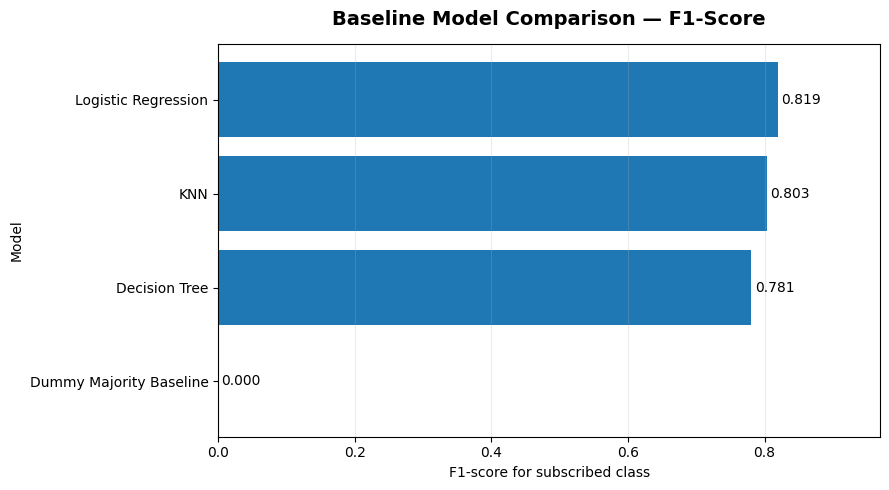

In [11]:
# Baseline model comparison chart using F1-score.
# This shows which simple model performs best before ensemble modelling.

chart_data = baseline_results_rounded.sort_values("F1_Score", ascending=True)

plt.figure(figsize=(9, 5))
bars = plt.barh(chart_data["Model"], chart_data["F1_Score"])
plt.title("Baseline Model Comparison — F1-Score", fontsize=14, weight="bold", pad=14)
plt.xlabel("F1-score for subscribed class")
plt.ylabel("Model")
plt.grid(axis="x", alpha=0.25)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height() / 2, f"{width:.3f}", va="center", fontsize=10)

plt.xlim(0, min(1.0, chart_data["F1_Score"].max() + 0.15))
plt.tight_layout()
plt.show()

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom:6px;">Confusion matrix for best baseline</h3>
<p>
The confusion matrix shows where the best baseline model is correct or wrong. This is important before ensemble work because we need to know what kind of mistakes the baseline makes.
</p>

</div>

Best baseline by F1-score: Logistic Regression

Classification report:
                precision    recall  f1-score   support

Not subscribed       0.84      0.84      0.84      1175
    Subscribed       0.82      0.82      0.82      1058

      accuracy                           0.83      2233
     macro avg       0.83      0.83      0.83      2233
  weighted avg       0.83      0.83      0.83      2233



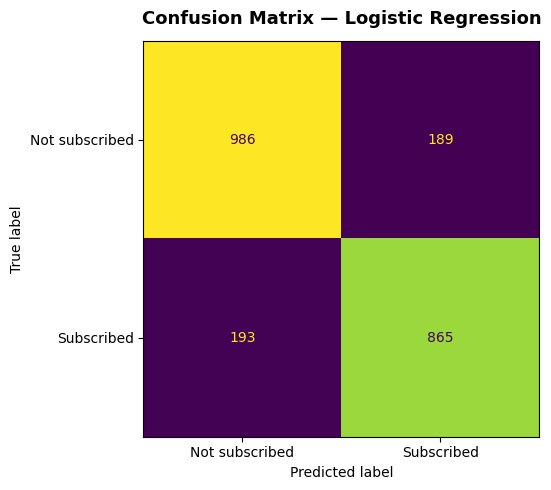

In [ ]:
# Select the best baseline model by F1-score and inspect its confusion matrix.
# This helps us understand where the model makes mistakes:
# - False positives: predicted subscribed, but actually not subscribed
# - False negatives: predicted not subscribed, but actually subscribed

# ------------------------------------------------------------
# 1. Select the best baseline model
# ------------------------------------------------------------

# baseline_results is already sorted by F1_Score in descending order.
# Therefore, the first row contains the best baseline model.

best_baseline_name = baseline_results.iloc[0]["Model"]

# Retrieve the trained pipeline for the best model.
# This pipeline includes both preprocessing + model.

best_baseline_model = trained_baselines[best_baseline_name]

# Predict the test set using the best baseline model.
# Output: 0 = Not subscribed, 1 = Subscribed

best_y_pred = best_baseline_model.predict(X_test)


# ------------------------------------------------------------
# 2. Print classification report
# ------------------------------------------------------------

print(f"Best baseline by F1-score: {best_baseline_name}")

# \n adds a clean blank line before the report.

print("\nClassification report:")

# Classification report shows precision, recall, F1-score, and support for each class.
# This is more detailed than accuracy alone.

print(
    classification_report(
        y_test,
        best_y_pred,
        target_names=["Not subscribed", "Subscribed"],
        zero_division=0
    )
)


# ------------------------------------------------------------
# 3. Create confusion matrix
# ------------------------------------------------------------

# Confusion matrix compares actual labels vs predicted labels.

cm = confusion_matrix(y_test, best_y_pred)

# Prepare a readable confusion matrix display.

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not subscribed", "Subscribed"]
)


# ------------------------------------------------------------
# 4. Plot confusion matrix
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 5))

# values_format=",d" displays numbers with commas if they are large.
# colorbar=False keeps the chart cleaner for notebook storytelling.

display_cm.plot(
    ax=ax,
    values_format=",d",
    colorbar=False
)

plt.title(
    f"Confusion Matrix — {best_baseline_name}",
    fontsize=13,
    weight="bold",
    pad=12
)

plt.tight_layout()
plt.show()

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Conclusion: Confusion Matrix for Logistic Regression</h3>

<p>
The confusion matrix shows how the best baseline model, <b>Logistic Regression</b>, performs on the test set.
The model correctly predicted <b>986 non-subscribers</b> and <b>865 subscribers</b>.
</p>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Correct predictions:</b><br>
  <b>986</b> customers were correctly predicted as not subscribed.<br>
  <b>865</b> customers were correctly predicted as subscribed.
</div>

<p>
The model made <b>189 false positive predictions</b>. These are customers predicted as subscribers,
but they actually did not subscribe. In a marketing campaign, this could lead to wasted contact effort.
</p>

<p>
The model also made <b>193 false negative predictions</b>. These are customers predicted as not subscribed,
but they actually subscribed. From a business point of view, these are missed campaign opportunities.
</p>

<div style="
  border-left: 4px solid #f59e0b;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Important point for understanding:</b><br>
  The false positives and false negatives are very close:
  <b>189 vs. 193</b>. This means the model is not heavily biased toward only one type of error.
</div>

<p>
Overall, Logistic Regression gives a strong and balanced baseline.
In the next notebook, Random Forest must show whether using many decision trees can reduce these errors
and improve the overall prediction quality.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom:6px;">Save outputs for later notebooks</h3>
<p>
The next cell saves baseline results, train/test split files, and the trained baseline pipelines. Later notebooks can reuse these outputs or recompute from the raw data when needed.
</p>

</div>

In [14]:
# Save reusable outputs for later Day 9 notebooks.
# These files keep the workflow organized and submission-ready.

baseline_results_rounded.to_csv(reports_dir / "day9_baseline_model_results.csv", index=False)
split_summary.to_csv(reports_dir / "day9_train_test_split_summary.csv", index=False)
target_summary.to_csv(reports_dir / "day9_target_distribution.csv", index=False)

X_train.to_csv(processed_dir / "day9_X_train_raw.csv", index=False)
X_test.to_csv(processed_dir / "day9_X_test_raw.csv", index=False)
y_train.to_csv(processed_dir / "day9_y_train.csv", index=False)
y_test.to_csv(processed_dir / "day9_y_test.csv", index=False)

joblib.dump(trained_baselines, models_dir / "day9_trained_baseline_pipelines.joblib")

print("Saved files:")
print(f"- {reports_dir / 'day9_baseline_model_results.csv'}")
print(f"- {reports_dir / 'day9_train_test_split_summary.csv'}")
print(f"- {reports_dir / 'day9_target_distribution.csv'}")
print(f"- {processed_dir / 'day9_X_train_raw.csv'}")
print(f"- {processed_dir / 'day9_X_test_raw.csv'}")
print(f"- {processed_dir / 'day9_y_train.csv'}")
print(f"- {processed_dir / 'day9_y_test.csv'}")
print(f"- {models_dir / 'day9_trained_baseline_pipelines.joblib'}")

Saved files:
- reports/day9_baseline_model_results.csv
- reports/day9_train_test_split_summary.csv
- reports/day9_target_distribution.csv
- data/processed/day9_X_train_raw.csv
- data/processed/day9_X_test_raw.csv
- data/processed/day9_y_train.csv
- data/processed/day9_y_test.csv
- models/day9_trained_baseline_pipelines.joblib


<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom:6px;">Conclusion</h3>

<div style="border-left:4px solid #22c55e; padding:10px 14px; margin:12px 0; background:var(--vscode-editorWidget-background); border-radius:6px;">
<strong>What we completed:</strong> We loaded and standardized the Bank Marketing dataset, inspected class balance, created a fair train/test split, built a reusable preprocessing pipeline, trained baseline models, compared them using business-relevant metrics, and saved reusable outputs for the ensemble notebooks.
</div>

<p>
The next notebook will move from baseline modelling to <strong>Bagging, Random Forest, Random Subspace Method, OOB evaluation, and feature importance</strong>. That will directly connect to the first part of the MVD and the Random Forest lecture material.
</p>

</div>

<div style="
  font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Arial, sans-serif;
  line-height: 1.55;
  color: var(--vscode-editor-foreground);
">

<h3 style="margin-bottom: 6px;">Final Conclusion: Notebook 2</h3>

<p>
Notebook 2 prepared the Bank Marketing dataset for the Day 9 ensemble modelling workflow.
The dataset was cleaned, the target variable was standardized, feature groups were identified,
and the data was split into training and test sets.
</p>

<div style="
  border-left: 4px solid #22c55e;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Main result:</b><br>
  Logistic Regression is the strongest baseline model so far, with
  <b>82.89% accuracy</b>, <b>81.91% F1-score</b>, and <b>90.71% ROC-AUC</b>.
</div>

<p>
The target distribution is nearly balanced, with <b>52.6% not subscribed</b> and
<b>47.4% subscribed</b>. This means accuracy is useful as a first metric, but
precision, recall, F1-score, and ROC-AUC will still be tracked for a more complete
marketing prediction evaluation.
</p>

<p>
The confusion matrix showed that Logistic Regression correctly predicted
<b>986 non-subscribers</b> and <b>865 subscribers</b>. The model made
<b>189 false positives</b> and <b>193 false negatives</b>, so the two main error types
are balanced.
</p>

<div style="
  border-left: 4px solid #38bdf8;
  padding: 10px 14px;
  margin: 12px 0;
  background: var(--vscode-editorWidget-background);
  border-radius: 6px;
">
  <b>Important point for the next notebook:</b><br>
  Random Forest must now prove whether many decision trees can improve over the single
  Decision Tree and the strong Logistic Regression baseline.
</div>

<p>
All important reusable outputs were saved for the next Day 9 notebooks, including the
train/test data, target distribution, split summary, baseline comparison table, and trained
baseline pipelines.
</p>

</div>